# 03 · Do early-career signals predict what comes next?

Notebook 02 showed that across the league, plate discipline repeats reliably but adds little to a production forecast. This notebook asks the prospect version of the question, with the timing kept honest: every signal is measured on a player's **first 250 MLB plate appearances**, and the outcome is his **wOBA over the next 600 (PA 251–850)**. Nothing about the outcome is used to build the signals.

It also tests a five-gate "readiness" checklist from an earlier version of this project (breaking-ball chase, offspeed chase, whiff rate against 96+ mph, overall chase, and zone contact). That version set each threshold from the players already labeled stars, which lets the outcome leak into the test. Here each gate is passed by beating the **median qualified MLB hitter** (300+ PA, 2021–2026), so the thresholds carry no outcome information.

In [1]:
import sys
import warnings

warnings.filterwarnings("ignore", message=".*urllib3.*")
sys.path.insert(0, "../src")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("../outputs/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.precision", 3)

from scipy import stats

from yanks_analytics.data.prospects import get_prospect_df
from yanks_analytics.data.statcast import load_seasons
from yanks_analytics.features.season import season_table, window_table

EARLY = (0, 250)
LATER = (250, 850)

In [2]:
cohort = get_prospect_df().set_index("mlbam_id")
pitches = load_seasons(range(2020, 2027))
pitches = pitches[pitches["batter"].isin(cohort.index)]

early = window_table(pitches, *EARLY)
later = window_table(pitches, *LATER)
panel = early.join(later[["wOBA", "xwOBA"]].add_suffix("_later"), how="inner")
panel = cohort[["name", "org"]].join(panel, how="inner")
print(f"{len(panel)} of {len(cohort)} players have {LATER[1]}+ MLB plate appearances")

35 of 43 players have 850+ MLB plate appearances


## 1. Early signals vs. later wOBA

Spearman rank correlations with 95% bootstrap intervals (players resampled). With about 35 players, an interval that spans zero is the expected result for a weak signal, and testing many metrics means one or two will look significant by chance.

In [3]:
SIGNALS = ["wOBA", "xwOBA", "chase", "chase_breaking", "chase_offspeed", "zone_contact",
           "whiff", "whiff_96plus", "whiff_breaking", "whiff_two_strike"]
rng = np.random.default_rng(2026)

def spearman_ci(x, y, n_boot=4000):
    n, values = len(x), []
    for _ in range(n_boot):
        i = rng.integers(0, n, n)
        values.append(stats.spearmanr(x[i], y[i]).statistic)
    return np.nanpercentile(values, [2.5, 97.5])

rows = []
y = panel["wOBA_later"].to_numpy()
for m in SIGNALS:
    x = panel[m].to_numpy()
    rho, p = stats.spearmanr(x, y)
    lo, hi = spearman_ci(x, y)
    rows.append({"early signal": m, "rho": rho, "95% CI": f"[{lo:.2f}, {hi:.2f}]", "p": p})
early_signals = pd.DataFrame(rows).set_index("early signal")
early_signals.to_csv(DATA_DIR / "early_signals.csv")
early_signals.round(2)

,rho,95% CI,p
early signal,,,
wOBA,0.36,"[0.02, 0.63]",0.03
xwOBA,0.29,"[-0.02, 0.58]",0.09
chase,-0.02,"[-0.39, 0.36]",0.92
chase_breaking,0.03,"[-0.33, 0.38]",0.88
chase_offspeed,0.05,"[-0.31, 0.42]",0.77
zone_contact,-0.22,"[-0.49, 0.10]",0.21
whiff,0.26,"[-0.07, 0.54]",0.13
whiff_96plus,0.21,"[-0.13, 0.51]",0.24
whiff_breaking,0.20,"[-0.13, 0.49]",0.25


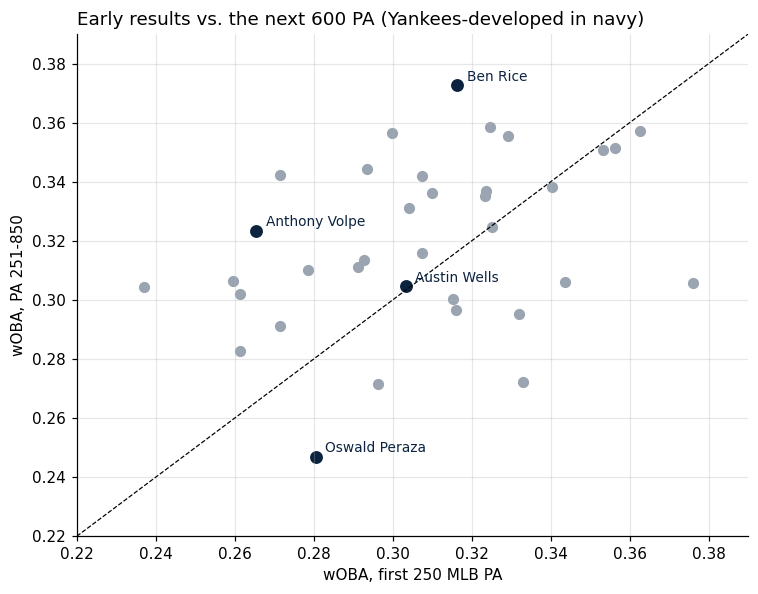

In [4]:
fig, ax = plt.subplots(figsize=(7, 5.5))
is_nyy = panel["org"] == "NYY"
ax.scatter(panel.loc[~is_nyy, "wOBA"], panel.loc[~is_nyy, "wOBA_later"], color="#9aa5b1", s=40)
ax.scatter(panel.loc[is_nyy, "wOBA"], panel.loc[is_nyy, "wOBA_later"], color="#0c2340", s=55)
for _, r in panel[is_nyy].iterrows():
    ax.annotate(r["name"], (r["wOBA"], r["wOBA_later"]), textcoords="offset points",
                xytext=(6, 3), fontsize=9, color="#0c2340")
lims = [0.22, 0.39]
ax.plot(lims, lims, color="black", linewidth=0.8, linestyle="--")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("wOBA, first 250 MLB PA")
ax.set_ylabel("wOBA, PA 251-850")
ax.set_title("Early results vs. the next 600 PA (Yankees-developed in navy)", loc="left")
fig.tight_layout()
fig.savefig(FIG_DIR / "early_vs_later_woba.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Readiness gates

In [5]:
GATES = {"chase_breaking": "<", "chase_offspeed": "<", "whiff_96plus": "<",
         "chase": "<", "zone_contact": ">"}

league = pd.concat([season_table(load_seasons([s])) for s in range(2021, 2027)])
league = league[league["PA"] >= 300]
thresholds = pd.Series({m: league[m].median() for m in GATES}, name="league median")
print(f"Thresholds from {len(league):,} qualified batter-seasons")
thresholds.round(3).to_frame()

Thresholds from 1,654 qualified batter-seasons


,league median
chase_breaking,0.327
chase_offspeed,0.363
whiff_96plus,0.192
chase,0.308
zone_contact,0.866


In [6]:
passed = pd.DataFrame({
    m: (panel[m] < t) if GATES[m] == "<" else (panel[m] > t) for m, t in thresholds.items()
})
panel["gates_passed"] = passed.sum(axis=1)
rho, p = stats.spearmanr(panel["gates_passed"], panel["wOBA_later"])
lo, hi = spearman_ci(panel["gates_passed"].to_numpy(), panel["wOBA_later"].to_numpy())
print(f"Gates passed (first 250 PA) vs wOBA over PA 251-850: rho = {rho:.2f}, 95% CI [{lo:.2f}, {hi:.2f}], p = {p:.2f}")
(panel.groupby("gates_passed")["wOBA_later"].agg(players="count", mean_later_wOBA="mean")
 .round(3))

Gates passed (first 250 PA) vs wOBA over PA 251-850: rho = -0.18, 95% CI [-0.51, 0.18], p = 0.30

,players,mean_later_wOBA
gates_passed,,
0,9,0.328
1,4,0.325
2,7,0.319
3,3,0.325
4,9,0.306
5,3,0.327


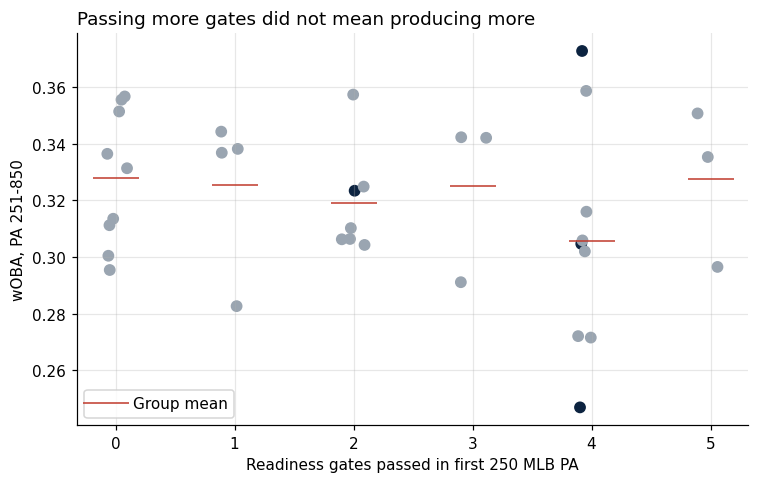

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
jitter = rng.uniform(-0.12, 0.12, len(panel))
ax.scatter(panel["gates_passed"] + jitter, panel["wOBA_later"],
           c=np.where(panel["org"] == "NYY", "#0c2340", "#9aa5b1"), s=45)
means = panel.groupby("gates_passed")["wOBA_later"].mean()
ax.plot(means.index, means.values, color="#c0392b", marker="_", markersize=30, linestyle="none",
        label="Group mean")
ax.set_xticks(range(6))
ax.set_xlabel("Readiness gates passed in first 250 MLB PA")
ax.set_ylabel("wOBA, PA 251-850")
ax.set_title("Passing more gates did not mean producing more", loc="left")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(FIG_DIR / "readiness_gates.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
(panel[["name", "org", "gates_passed", "wOBA", "xwOBA", "wOBA_later"]]
 .rename(columns={"wOBA": "wOBA_first250", "xwOBA": "xwOBA_first250"})
 .sort_values("wOBA_later", ascending=False).reset_index(drop=True))

,name,org,gates_passed,wOBA_first250,xwOBA_first250,wOBA_later
0,Ben Rice,NYY,4,0.316,0.369,0.373
1,Gunnar Henderson,BAL,4,0.325,0.334,0.359
2,Corbin Carroll,ARI,2,0.363,0.315,0.357
3,Junior Caminero,TB,0,0.300,0.292,0.357
4,Julio Rodriguez,SEA,0,0.329,0.294,0.355
5,Michael Harris II,ATL,0,0.356,0.334,0.351
6,Adley Rutschman,BAL,5,0.353,0.348,0.351
7,Jackson Chourio,MIL,1,0.294,0.286,0.344
8,Riley Greene,DET,3,0.271,0.303,0.342
9,Jordan Westburg,BAL,3,0.307,0.318,0.342


## Findings

- **Early production carries some signal; early discipline carries almost none.** A player's wOBA over his first 250 PA is the only early measure whose interval excludes zero (ρ = .36, 95% CI .02 to .63). All three chase rates sit near zero (ρ between −.02 and .05).
- **The whiff metrics lean the "wrong" way.** Prospects who whiffed more early did slightly better later, matching the league-wide pattern in notebook 02 where damage and swing-and-miss travel together. Two-strike whiff rate reaches p = .04, but with ten signals tested one result near that level is expected by chance, so it is not treated as a finding.
- **The readiness gates did not identify who would produce.** Gates passed in the first 250 PA had no positive relationship with wOBA over the next 600 (ρ = −.18, 95% CI −.51 to .18), and group means are flat from zero gates to five. Oswald Peraza passed four gates and posted the cohort's lowest later wOBA (.247). Julio Rodríguez, Michael Harris II, and Junior Caminero passed none and all finished above .350.
- **Jasson Dominguez is not in this panel** because he has 749 career PA, short of the 850 the design requires.

**Limits:** 35 players, hand-picked, with intervals wide enough that modest real effects in either direction cannot be ruled out. The results say the gates are not validated, not that plate discipline is irrelevant.